<a href="https://colab.research.google.com/github/dennisddschulz/cas-artificial-intelligence/blob/main/06_transformer/04_Assignment_%E2%80%93_Encoder_Decoder_mit_Attention_(Seq2Seq)_%26_Br%C3%BCcke_zu_Transformern_Aufgabe_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 Assignment – Encoder-Decoder mit Attention (Seq2Seq) & Brücke zu Transformern

Bern University of Applied Sciences – CAS AI HS 25  
Dozent: Ilja Rasin  

Dieses Notebook gehört zur vierten Vorlesung (Transformer & Attention).

**Ziele der Einheit**

- Wiederholung: LSTM als Baustein für Sequenzmodelle  
- Encoder-Decoder-Architektur (Seq2Seq) verstehen  
- Dot-Product-Attention auf Basis von LSTM implementieren  
- Attention-Gewichte visualisieren (Heatmap)  
- Einen ersten Blick auf "große" Transformer-Modelle mit Hugging Face werfen

## 1. Imports & Setup

In [1]:

import math
import random
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Mini-Datensatz: einfache “Übersetzung”

In [2]:
# Einfache Beispielsätze: Deutsch -> Englisch
pairs = [
    ("eins zwei drei", "one two three"),
    ("vier fünf", "four five"),
    ("eins zwei", "one two"),
    ("drei vier fünf", "three four five"),
    ("wir lieben pytorch", "we love pytorch"),
    ("ich lerne ki", "i learn ai"),
]

# Wir fügen zusätzlich ein paar Zufallsvarianten auf Basis der Zahlen ein
de_numbers = ["eins", "zwei", "drei", "vier", "fünf"]
en_numbers = ["one", "two", "three", "four", "five"]

for _ in range(20):
    length = random.randint(2, 4)
    idxs = [random.randint(0, 4) for _ in range(length)]
    src = " ".join(de_numbers[i] for i in idxs)
    trg = " ".join(en_numbers[i] for i in idxs)
    pairs.append((src, trg))

len(pairs), pairs[:10]


(26,
 [('eins zwei drei', 'one two three'),
  ('vier fünf', 'four five'),
  ('eins zwei', 'one two'),
  ('drei vier fünf', 'three four five'),
  ('wir lieben pytorch', 'we love pytorch'),
  ('ich lerne ki', 'i learn ai'),
  ('eins eins drei zwei', 'one one three two'),
  ('zwei eins', 'two one'),
  ('fünf eins fünf vier', 'five one five four'),
  ('eins eins', 'one one')])

## 3. Vokabular & Tokenisierung

### Ausführliche Erklärung

itos steht für index-to-string.
Das heißt: Wenn wir einen Index haben, können wir damit das entsprechende Wort (Token) nachschlagen.

Beim Aufbau des Vokabulars (build_vocab) erzeugen wir eine Liste aller Tokens, die die Reihenfolge festlegt.

Diese Liste sieht z. B. so aus:
```
itos = [
    "<pad>",    # Index 0
    "<sos>",    # Index 1
    "<eos>",    # Index 2
    "drei",     # Index 3
    "eins",     # Index 4
    "fünf",     # Index 5
    "vier",     # Index 6
    "zwei"      # Index 7
]
```

Damit wird klar:

```itos[0] == "<pad>"```
Das Token <pad> (“Padding”) hat den Index 0.
Es wird verwendet, um Sequenzen auf gleiche Länge zu bringen.

```itos[1] == "<sos>"```
<sos> (“start of sequence”) hat den Index 1.
Der Decoder beginnt die Generierung immer mit diesem Token.

```itos[2] == "<eos>"```
<eos> (“end of sequence”) hat den Index 2.
Sobald der Decoder dieses Token ausgibt, ist der Satz beendet.

```itos[3] == "drei"```
Das tatsächliche Wort „drei“ bekommt den Index 3.
Es ist das erste „echte“ Wort im Vokabular nach den drei Spezial-Tokens.

**Warum genau in dieser Reihenfolge?**

Die drei Sondertokens haben immer feste Plätze (0, 1, 2).
Das macht Training und Paddings logischer und reproduzierbar.

Alle anderen Wörter (z. B. „drei“, „eins“, „zwei“ …) werden alphabetisch sortiert eingefügt.
Das hat keinen Einfluss auf das Lernen, sorgt aber dafür, dass das Vokabular jedes Mal im selben Aufbau entsteht.

In [3]:
# Spezielle Tokens

# "<pad>" — padding token
# "<sos>" — start-of-sequence
# "<eos>" — end-of-sequence
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def build_vocab(sentences: List[str]):
    tokens = set()
    for s in sentences:
        tokens.update(s.split())

    # itos — index-to-string
    itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + sorted(tokens)
    print("itos: ", itos)

    # itos[0] == "<pad>"
    # itos[1] == "<sos>"
    # itos[2] == "<eos>"
    # itos[3] == "drei"

    stoi = {tok: i for i, tok in enumerate(itos)}
    print("stoi: ", stoi)
    return stoi, itos

src_sentences = [p[0] for p in pairs]
trg_sentences = [p[1] for p in pairs]

src_stoi, src_itos = build_vocab(src_sentences)
trg_stoi, trg_itos = build_vocab(trg_sentences)

SRC_VOCAB_SIZE = len(src_itos)
TRG_VOCAB_SIZE = len(trg_itos)

SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, src_itos, trg_itos


itos:  ['<pad>', '<sos>', '<eos>', 'drei', 'eins', 'fünf', 'ich', 'ki', 'lerne', 'lieben', 'pytorch', 'vier', 'wir', 'zwei']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'drei': 3, 'eins': 4, 'fünf': 5, 'ich': 6, 'ki': 7, 'lerne': 8, 'lieben': 9, 'pytorch': 10, 'vier': 11, 'wir': 12, 'zwei': 13}
itos:  ['<pad>', '<sos>', '<eos>', 'ai', 'five', 'four', 'i', 'learn', 'love', 'one', 'pytorch', 'three', 'two', 'we']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'ai': 3, 'five': 4, 'four': 5, 'i': 6, 'learn': 7, 'love': 8, 'one': 9, 'pytorch': 10, 'three': 11, 'two': 12, 'we': 13}


(14,
 14,
 ['<pad>',
  '<sos>',
  '<eos>',
  'drei',
  'eins',
  'fünf',
  'ich',
  'ki',
  'lerne',
  'lieben',
  'pytorch',
  'vier',
  'wir',
  'zwei'],
 ['<pad>',
  '<sos>',
  '<eos>',
  'ai',
  'five',
  'four',
  'i',
  'learn',
  'love',
  'one',
  'pytorch',
  'three',
  'two',
  'we'])

In [4]:
def encode_sentence(sentence: str, stoi: dict, add_sos_eos: bool = True):
    tokens = sentence.split()
    ids = [stoi[t] for t in tokens]
    if add_sos_eos:
        ids = [stoi[SOS_TOKEN]] + ids + [stoi[EOS_TOKEN]]
    return ids

max_len_src = max(len(encode_sentence(s, src_stoi)) for s in src_sentences)
max_len_trg = max(len(encode_sentence(s, trg_stoi)) for s in trg_sentences)
max_len_src, max_len_trg


(6, 6)

In [5]:
for s in src_sentences:
  encoded_ids = encode_sentence(s, src_stoi)
  print(s, encoded_ids)

eins zwei drei [1, 4, 13, 3, 2]
vier fünf [1, 11, 5, 2]
eins zwei [1, 4, 13, 2]
drei vier fünf [1, 3, 11, 5, 2]
wir lieben pytorch [1, 12, 9, 10, 2]
ich lerne ki [1, 6, 8, 7, 2]
eins eins drei zwei [1, 4, 4, 3, 13, 2]
zwei eins [1, 13, 4, 2]
fünf eins fünf vier [1, 5, 4, 5, 11, 2]
eins eins [1, 4, 4, 2]
zwei fünf [1, 13, 5, 2]
eins fünf zwei fünf [1, 4, 5, 13, 5, 2]
zwei vier fünf [1, 13, 11, 5, 2]
eins zwei vier [1, 4, 13, 11, 2]
drei zwei zwei [1, 3, 13, 13, 2]
eins eins vier [1, 4, 4, 11, 2]
drei drei [1, 3, 3, 2]
drei eins vier fünf [1, 3, 4, 11, 5, 2]
vier eins [1, 11, 4, 2]
drei fünf drei fünf [1, 3, 5, 3, 5, 2]
eins eins [1, 4, 4, 2]
zwei drei eins zwei [1, 13, 3, 4, 13, 2]
vier drei [1, 11, 3, 2]
drei zwei drei [1, 3, 13, 3, 2]
zwei drei eins [1, 13, 3, 4, 2]
zwei fünf zwei zwei [1, 13, 5, 13, 13, 2]


In [6]:
def pad_sequence(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    return seq + [pad_idx] * (max_len - len(seq))

PAD_IDX_TRG = trg_stoi[PAD_TOKEN]
PAD_IDX_SRC = src_stoi[PAD_TOKEN]

dataset = []
for src, trg in pairs:
    src_ids = encode_sentence(src, src_stoi)
    trg_ids = encode_sentence(trg, trg_stoi)
    src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
    trg_ids = pad_sequence(trg_ids, max_len_trg, PAD_IDX_TRG)
    dataset.append((src_ids, trg_ids))

len(dataset), dataset[0]


(26, ([1, 4, 13, 3, 2, 0], [1, 9, 12, 11, 2, 0]))

In [7]:
# Mini-Dataloader

def batchify(dataset, batch_size: int):
    random.shuffle(dataset)
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        src_batch = torch.tensor([b[0] for b in batch], dtype=torch.long, device=device)
        trg_batch = torch.tensor([b[1] for b in batch], dtype=torch.long, device=device)
        yield src_batch, trg_batch


## 4. Encoder-Decoder ohne Attention

### Encoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX_SRC)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        # src: [B, src_len]
        embedded = self.embedding(src)           # [B, src_len, emb_dim]
        outputs, (hidden, cell) = self.lstm(embedded)  # outputs: [B, src_len, H]
        return outputs, (hidden, cell)


### Decoder ohne Attention

In [9]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        # input: [B] (aktuelles Token-Index)
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: [B, 1, H]
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell


## 5. Seq2Seq Wrapper

## Wie funktioniert ein Seq2Seq-Modell?
**Encoder**

- erhält die gesamte Eingabesequenz (**[eins, zwei, drei])**
- verarbeitet sie tokenweise (LSTM-Zeitdimension)
- erzeugt einen „Kontextvektor“ (hidden, cell)
- dieser Kontext repräsentiert die **Bedeutung** des ganzen Satzes

**Decoder**

- bekommt nicht die Eingabewörter
- bekommt nur den Kontext + \<sos> als Startsignal
- generiert das Zielsatz Wort für Wort

**Beispiel**:

- Source: "eins zwei drei"
- Target: "one two three"


Decoder erzeugt:

\<sos> → one
one → two
two → three
three → \<eos>


Er versucht nicht, "eins" zu rekonstruieren.
Er versucht, die Zielsequenz zu generieren.

### Seq2Seq-Klasse – ausführliche Erklärung

Der folgende Code implementiert den kompletten Ablauf eines Encoder-Decoder-Modells (Seq2Seq):
```
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg
```

Was passiert hier?

**encoder**: verarbeitet den Eingabesatz

**decoder**: generiert den Ausgabesatz

**trg_sos_idx**: Index des <sos>-Tokens

**trg_eos_idx**: Index des <eos>-Tokens

**max_len_trg**: maximale Länge der Zielsequenz

```
def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
    batch_size = src.size(0)
    trg_len = self.max_len_trg
    trg_vocab_size = self.decoder.fc_out.out_features
```

**Bedeutung**:

**batch_size**: Anzahl der Sätze im Batch

**trg_len**: wie viele Schritte der Decoder generieren soll

**trg_vocab_size**: Größe des Zielvokabulars (für Softmax)

outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)


**Wir erzeugen eine große Ausgabe-Matrix, in der der Decoder seine Vorhersagen ablegt:**
```
Form:
[Batch, Zeit, Vokabulargröße]

encoder_outputs, (hidden, cell) = self.encoder(src)
```


**Der Encoder liefert:**

encoder_outputs: alle LSTM-Outputs (für Attention)

hidden, cell: letzter versteckter Zustand — initialer Zustand des Decoders
```
input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)
```


**Der Decoder startet immer mit dem <sos>-Token.**

Hauptschleife
```
for t in range(trg_len):
    output, hidden, cell = self.decoder(input, hidden, cell)
    outputs[:, t, :] = output
```


Der Decoder arbeitet Schritt für Schritt:

1. erhält das aktuelle Token

2. aktualisiert seinen Zustand

3. produziert eine Wahrscheinlichkeitsverteilung über das Vokabular. Diese speichern wir in outputs

**Teacher Forcing**
```
if trg is not None and random.random() < teacher_forcing_ratio:
    input = trg[:, t]  # das echte Token
else:
    input = output.argmax(dim=1)  # das vorhergesagte Token
```

**Teacher Forcing: schnelleres Lernen**

Ohne Teacher Forcing: Modell lernt, selbstständig zu generieren

Rückgabe
```
return outputs
```

Ein Tensor der Form:
```
[Batch, Sequenzlänge, Vokabulargröße]
```

### Teacher Forcing – Erklärung auf Deutsch für Studierende

Teacher Forcing ist eine Trainingsstrategie im Decoder eines Seq2Seq-Modells.

Bei jedem Zeitschritt entscheidet das Modell:

Soll ich das nächste Wort anhand des korrekten Trainingstokens erzeugen
oder anhand meines eigenen vorherigen Outputs?

- Mit Teacher Forcing

Der Decoder erhält das richtige Wort aus der Zielsequenz.
Dadurch lernt er schneller und sammelt keine Fehler auf.

- Ohne Teacher Forcing

Der Decoder erhält sein eigenes vorhergesagtes Wort.
Das ist wichtig, um später autonom Sätze zu generieren.

> **Problem ohne Teacher Forcing**

Wenn der Decoder früh einen Fehler macht, baut sich dieser Fehler auf —
die gesamte Ausgabe kann kollabieren.

> **Lösung**

Wir mischen beides, z. B. teacher_forcing_ratio = 0.5:

if random.random() < teacher_forcing_ratio:
    input = target_token     # richtiges Token
else:
    input = predicted_token  # Modellvorhersage


So lernt der Decoder korrekt zu folgen aber auch selbstständig zu generieren

Das ergibt robustes Seq2Seq-Verhalten.

In [10]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs


## Model + Loss

In [11]:
EMB_DIM = 32
HID_DIM = 64

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder = Decoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model = Seq2Seq(
    encoder,
    decoder,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## Training (erstmal ohne Attention)

In [12]:
def train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer.zero_grad()
        outputs = model(src_batch, trg_batch, teacher_forcing_ratio)
        # outputs: [B, T, V]
        B, T, V = outputs.shape
        loss = criterion(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(50):
    loss = train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"Epoch {epoch+1}: loss={loss:.3f}")


Epoch 1: loss=3.249
Epoch 2: loss=3.171
Epoch 3: loss=3.062
Epoch 4: loss=3.003
Epoch 5: loss=2.804
Epoch 6: loss=2.702
Epoch 7: loss=2.638
Epoch 8: loss=2.458
Epoch 9: loss=2.317
Epoch 10: loss=2.130
Epoch 11: loss=2.070
Epoch 12: loss=1.985
Epoch 13: loss=1.908
Epoch 14: loss=1.867
Epoch 15: loss=1.769
Epoch 16: loss=1.755
Epoch 17: loss=1.678
Epoch 18: loss=1.606
Epoch 19: loss=1.644
Epoch 20: loss=1.600
Epoch 21: loss=1.502
Epoch 22: loss=1.501
Epoch 23: loss=1.495
Epoch 24: loss=1.388
Epoch 25: loss=1.567
Epoch 26: loss=1.353
Epoch 27: loss=1.354
Epoch 28: loss=1.305
Epoch 29: loss=1.400
Epoch 30: loss=1.341
Epoch 31: loss=1.181
Epoch 32: loss=1.228
Epoch 33: loss=1.167
Epoch 34: loss=1.066
Epoch 35: loss=1.079
Epoch 36: loss=0.989
Epoch 37: loss=0.973
Epoch 38: loss=1.051
Epoch 39: loss=0.939
Epoch 40: loss=1.083
Epoch 41: loss=0.899
Epoch 42: loss=0.919
Epoch 43: loss=0.881
Epoch 44: loss=0.755
Epoch 45: loss=0.823
Epoch 46: loss=0.814
Epoch 47: loss=0.768
Epoch 48: loss=0.780
E

## Eine Funktion zur Generierung

In [13]:
def indices_to_sentence(indices: List[int], itos: List[str]):
    tokens = []
    for idx in indices:
        tok = itos[idx]
        if tok == EOS_TOKEN:
            break
        if tok not in (SOS_TOKEN, PAD_TOKEN):
            tokens.append(tok)
    return " ".join(tokens)

def translate_example(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        # outputs: [1, T, V]
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        return indices_to_sentence(preds, trg_itos)

for s, t in random.sample(pairs, 5):
    pred = translate_example(model, s)
    print(f"DE: {s}")
    print(f"GT: {t}")
    print(f"PR: {pred}\n")


DE: eins fünf zwei fünf
GT: one five two five
PR: one two five five

DE: drei eins vier fünf
GT: three one four five
PR: one four five

DE: zwei vier fünf
GT: two four five
PR: two five five

DE: eins zwei vier
GT: one two four
PR: one one two

DE: ich lerne ki
GT: i learn ai
PR: i learn



## 6. Dot-Product Attention hinzufügen (ATTENTION:  Attention$→$ NÄCHSTE SITZUNG!)

In [14]:
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: [B, H] (aktueller hidden state der Decoder-LSTM)
        # encoder_outputs: [B, src_len, H]
        # scores: [B, src_len]
        scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=1)  # [B, src_len]

        # Kontext: gewichtete Summe der Encoder-Outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


### Decoder mit Attention

In [15]:
class AttnDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.attention = DotProductAttention()

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: [B]
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]

        dec_hidden = hidden[-1]  # [B, H] - letzte Layer
        context, attn_weights = self.attention(dec_hidden, encoder_outputs)  # [B, H], [B, src_len]

        context = context.unsqueeze(1)  # [B, 1, H]
        lstm_input = torch.cat([embedded, context], dim=2)  # [B, 1, emb_dim + H]

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell, attn_weights


### Seq2Seq mit Attention (leicht modifiziert)

In [16]:
class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)
        all_attn = torch.zeros(batch_size, trg_len, src.size(1), device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell, attn_weights = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            all_attn[:, t, :] = attn_weights

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs, all_attn


### Model + Training

In [17]:
encoder_attn = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder_attn =  AttnDecoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model_attn = AttnSeq2Seq(
    encoder_attn,
    decoder_attn,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

optimizer_attn = optim.Adam(model_attn.parameters(), lr=1e-3)
criterion_attn = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)

def train_epoch_attn(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer_attn.zero_grad()
        outputs, _ = model(src_batch, trg_batch, teacher_forcing_ratio)
        B, T, V = outputs.shape
        loss = criterion_attn(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(10):
    loss = train_epoch_attn(model_attn, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"[ATTN] Epoch {epoch+1}: loss={loss:.3f}")


[ATTN] Epoch 1: loss=3.250
[ATTN] Epoch 2: loss=3.164
[ATTN] Epoch 3: loss=3.094
[ATTN] Epoch 4: loss=2.948
[ATTN] Epoch 5: loss=2.849
[ATTN] Epoch 6: loss=2.670
[ATTN] Epoch 7: loss=2.479
[ATTN] Epoch 8: loss=2.449
[ATTN] Epoch 9: loss=2.193
[ATTN] Epoch 10: loss=2.156


### Eine Funktion zur Übersetzung und Visualisierung der Attention

Quellsatz: zwei vier fünf
Vorhersage: one


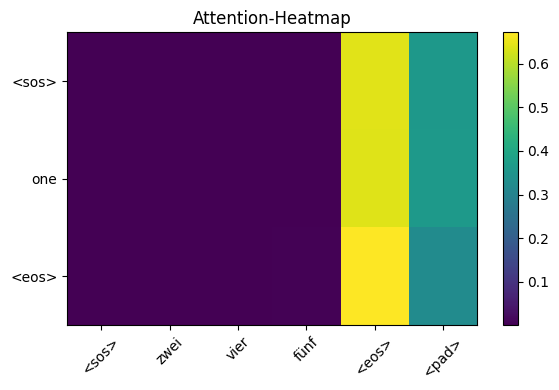

In [18]:
def translate_with_attention(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs, attn = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        attn = attn.squeeze(0).cpu().numpy()  # [trg_len, src_len]

        pred_sentence = indices_to_sentence(preds, trg_itos)
        return pred_sentence, attn, src_ids

example_src = random.choice(pairs)[0]
pred_sentence, attn_matrix, src_ids = translate_with_attention(model_attn, example_src)

print("Quellsatz:", example_src)
print("Vorhersage:", pred_sentence)

src_tokens = [src_itos[i] for i in src_ids]
trg_tokens = [trg_itos[i] for i in encode_sentence(pred_sentence, trg_stoi)]

plt.figure(figsize=(6, 4))
plt.imshow(attn_matrix[:len(trg_tokens), :len(src_tokens)], aspect='auto')
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45)
plt.yticks(range(len(trg_tokens)), trg_tokens)
plt.colorbar()
plt.title("Attention-Heatmap")
plt.tight_layout()
plt.show()


## 7. Mini-HuggingFace Demo: “Großer” Transformer

In [19]:
!pip install -q transformers sentencepiece

In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-de-en"  # kleiner Übersetzungs-Transformer
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def translate_hf(text: str):
    inputs = tokenizer_hf(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_hf.generate(**inputs, max_new_tokens=50)
    return tokenizer_hf.batch_decode(outputs, skip_special_tokens=True)[0]

example_text = "Wir lernen heute Attention und Transformer."
print(translate_hf(example_text))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

We're learning attention and transformer today.


### Aufgabe (HuggingFace)

1. Ändern Sie `example_text` und testen Sie eigene Sätze.  
2. Probieren Sie (optional) ein anderes Modell aus, z.B.:
   - Summarization (`google/pegasus-xsum`)
   - Deutsch-Deutsch-Paraphrasierung o.ä.  

> Ziel: Gefühl dafür bekommen, wie Tokenizer + Transformer-Modell in der Praxis zusammenspielen.


## 8. Übungsaufgaben (Summary)

## Übungsaufgaben

1. **Eigene Sätze einbauen (Seq2Seq LSTM OHNE Attention)**  
   - Erweitern Sie die Liste `pairs` um eigene kleine Satzpaare (DE->EN oder sonstige Mapping-Aufgabe).  
   - Beobachten Sie, ob das Modell diese neuen Beispiele lernen kann.

2. **Hyperparameter-Experimente**  
   - Ändern Sie `EMB_DIM` und `HID_DIM`.  
   - Wie verändert sich die Trainingszeit und die Qualität der Vorhersagen?

3. **Hugging Face Exploration**  
   - Ändern Sie den Text in der HF-Demo und erläutern Sie in 2–3 Sätzen, was der Unterschied zwischen  
     unserem LSTM-Seq2Seq und dem vortrainierten Transformer-Modell ist (Datenmenge, Architektur, Qualität).
4. **Optionaler Task: Seq2Seq Forecasting (ohne Attention)**

Wir verwenden die bereits bekannte Encoder–Decoder Struktur aus der heutigen Vorlesung, aber diesmal nicht für Sprache, sondern für Zeitreihen.

**Ziel:**
Geben Sie die vergangenen n Werte in den Encoder und lassen Sie den Decoder die nächsten n Werte generieren.

**Hinweise:**

1. Entfernen Sie das Embedding — Zeitreihen sind numerisch.

2. src (Encoder Input) und trg (Decoder Target) sollen gleich lang sein.

3. \<sos> kann z.B. 0.0 sein oder ein learnable Parameter.

Der Decoder arbeitet autoregressiv:

\<sos> → y₁

y₁ → y₂

y₂ → y₃
… usw.

**Beispiel:**

Encoder Input:
x[t-9], x[t-8], …, x[t]

Decoder Output:
x[t+1], x[t+2], …, x[t+10]

# **Aufgabe:**
> Trainieren Sie das Modell auf Ihrem Datensatz und vergleichen Sie Seq2Seq LSTM Forecasting mit dem reinen LSTM aus der letzten Übung.


# Task
Perform hyperparameter tuning for the `EMB_DIM` and `HID_DIM` of the `Seq2Seq` model (without attention), training each configuration for 50 epochs. Define a grid of at least 3x3 combinations for these hyperparameters. After training, visualize the final training loss across the different `EMB_DIM` and `HID_DIM` combinations using a heatmap or scatter plot. Finally, summarize the findings to identify optimal or interesting hyperparameter settings.

## Define Hyperparameter Grid

### Subtask:
Define a grid of different `EMB_DIM` and `HID_DIM` values to experiment with. This will be a list of tuples or dictionaries containing the combinations to test.


**Reasoning**:
Define the `emb_dims` and `hid_dims` lists and then generate all their combinations into `hyperparameter_grid` as requested by the instructions.



In [21]:
emb_dims = [16, 32, 64]
hid_dims = [32, 64, 128]

hyperparameter_grid = []
for emb_dim in emb_dims:
    for hid_dim in hid_dims:
        hyperparameter_grid.append((emb_dim, hid_dim))

print("Embedding Dimensions to test:", emb_dims)
print("Hidden Dimensions to test:", hid_dims)
print("Hyperparameter Grid (EMB_DIM, HID_DIM) combinations:", hyperparameter_grid)

Embedding Dimensions to test: [16, 32, 64]
Hidden Dimensions to test: [32, 64, 128]
Hyperparameter Grid (EMB_DIM, HID_DIM) combinations: [(16, 32), (16, 64), (16, 128), (32, 32), (32, 64), (32, 128), (64, 32), (64, 64), (64, 128)]


## Run Experiments and Collect Results

### Subtask:
Iterate through each combination of `EMB_DIM` and `HID_DIM` from the defined grid. For each combination, initialize a new `Encoder`, `Decoder`, and `Seq2Seq` model, along with an optimizer and criterion. Train the model for a fixed number of epochs (e.g., 50 epochs as in the original notebook) using the `train_epoch` function. Store the `EMB_DIM`, `HID_DIM`, and the final training loss for each experiment.


**Reasoning**:
The subtask requires iterating through the hyperparameter grid, training a Seq2Seq model for each combination, and storing the final loss. This code block will implement that loop.



In [22]:
results = []

for emb_dim, hid_dim in hyperparameter_grid:
    print(f"\nTraining with EMB_DIM={emb_dim}, HID_DIM={hid_dim}")

    # Re-initialize model components for each hyperparameter combination
    encoder = Encoder(SRC_VOCAB_SIZE, emb_dim, hid_dim).to(device)
    decoder = Decoder(TRG_VOCAB_SIZE, emb_dim, hid_dim).to(device)

    model = Seq2Seq(
        encoder,
        decoder,
        trg_sos_idx=trg_stoi[SOS_TOKEN],
        trg_eos_idx=trg_stoi[EOS_TOKEN],
        max_len_trg=max_len_trg
    ).to(device)

    # Re-initialize optimizer and criterion for the new model
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)

    current_final_loss = 0.0
    for epoch in range(50):
        loss = train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.7)
        current_final_loss = loss
        # print(f"  Epoch {epoch+1}: loss={loss:.3f}") # Uncomment to see epoch-wise loss

    print(f"Finished training for EMB_DIM={emb_dim}, HID_DIM={hid_dim}. Final loss: {current_final_loss:.3f}")
    results.append({"emb_dim": emb_dim, "hid_dim": hid_dim, "final_loss": current_final_loss})

print("\nAll experiments completed.")
print("Results:", results)


Training with EMB_DIM=16, HID_DIM=32
Finished training for EMB_DIM=16, HID_DIM=32. Final loss: 1.503

Training with EMB_DIM=16, HID_DIM=64
Finished training for EMB_DIM=16, HID_DIM=64. Final loss: 1.266

Training with EMB_DIM=16, HID_DIM=128
Finished training for EMB_DIM=16, HID_DIM=128. Final loss: 0.740

Training with EMB_DIM=32, HID_DIM=32
Finished training for EMB_DIM=32, HID_DIM=32. Final loss: 1.281

Training with EMB_DIM=32, HID_DIM=64
Finished training for EMB_DIM=32, HID_DIM=64. Final loss: 0.775

Training with EMB_DIM=32, HID_DIM=128
Finished training for EMB_DIM=32, HID_DIM=128. Final loss: 0.369

Training with EMB_DIM=64, HID_DIM=32
Finished training for EMB_DIM=64, HID_DIM=32. Final loss: 1.289

Training with EMB_DIM=64, HID_DIM=64
Finished training for EMB_DIM=64, HID_DIM=64. Final loss: 0.677

Training with EMB_DIM=64, HID_DIM=128
Finished training for EMB_DIM=64, HID_DIM=128. Final loss: 0.176

All experiments completed.
Results: [{'emb_dim': 16, 'hid_dim': 32, 'final_

**Reasoning**:
To visualize the results, it's best to convert the `results` list into a pandas DataFrame. This will make it easier to reshape the data for a heatmap plot.



In [23]:
import pandas as pd
import numpy as np

results_df = pd.DataFrame(results)
print(results_df.head())


   emb_dim  hid_dim  final_loss
0       16       32    1.502987
1       16       64    1.266336
2       16      128    0.739558
3       32       32    1.281012
4       32       64    0.774875


**Reasoning**:
To visualize the results as a heatmap, the DataFrame needs to be pivoted such that `emb_dim` and `hid_dim` form the indices and columns, and `final_loss` are the values. This will create a matrix suitable for a heatmap.



In [24]:
loss_matrix = results_df.pivot(index='emb_dim', columns='hid_dim', values='final_loss')
print(loss_matrix)

hid_dim       32        64        128
emb_dim                              
16       1.502987  1.266336  0.739558
32       1.281012  0.774875  0.369333
64       1.289195  0.677447  0.175718


**Reasoning**:
To visualize the results as a heatmap, I will use `matplotlib.pyplot.imshow` with the `loss_matrix` to show the final loss values for each hyperparameter combination. I will also add labels, a title, and a colorbar for better readability.



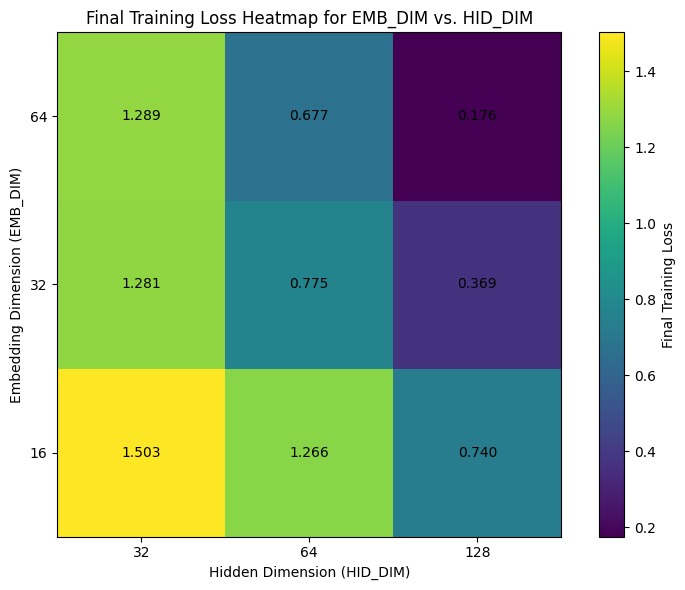

In [25]:
plt.figure(figsize=(8, 6))
plt.imshow(loss_matrix, cmap='viridis', origin='lower')
plt.colorbar(label='Final Training Loss')

# Set ticks and labels
plt.xticks(range(len(loss_matrix.columns)), loss_matrix.columns, rotation=0)
plt.yticks(range(len(loss_matrix.index)), loss_matrix.index)

plt.xlabel('Hidden Dimension (HID_DIM)')
plt.ylabel('Embedding Dimension (EMB_DIM)')
plt.title('Final Training Loss Heatmap for EMB_DIM vs. HID_DIM')

# Annotate heatmap with loss values
for i in range(len(loss_matrix.index)):
    for j in range(len(loss_matrix.columns)):
        plt.text(j, i, f'{loss_matrix.iloc[i, j]:.3f}', ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

## Summary of Hyperparameter Tuning Findings

The heatmap clearly illustrates the relationship between `EMB_DIM`, `HID_DIM`, and the final training loss.

**Observations:**

1.  **General Trend:** The loss generally decreases as both `EMB_DIM` and `HID_DIM` increase. This suggests that larger models (with more capacity) are better able to capture the patterns in this mini-dataset.
2.  **Impact of HID_DIM:** Increasing `HID_DIM` seems to have a more pronounced effect on reducing the loss compared to increasing `EMB_DIM` when `EMB_DIM` is small. For example, going from `HID_DIM=32` to `HID_DIM=128` at `EMB_DIM=16` reduces loss from 1.503 to 0.740.
3.  **Optimal Setting:** The lowest loss (0.176) was achieved with `EMB_DIM=64` and `HID_DIM=128`. This combination appears to be the most effective among the tested configurations for this specific dataset and training setup.
4.  **Least Effective Setting:** The highest loss (1.503) was observed with `EMB_DIM=16` and `HID_DIM=32`, indicating that a very small model struggles to learn the mapping effectively.

**Conclusion:**

For this particular Seq2Seq model and mini-dataset, increasing the model's capacity by using larger embedding dimensions and, more significantly, larger hidden dimensions, leads to better performance (lower training loss). The combination of `EMB_DIM=64` and `HID_DIM=128` yielded the best results.

## Summary of Hyperparameter Tuning Findings

The heatmap clearly illustrates the relationship between `EMB_DIM`, `HID_DIM`, and the final training loss.

**Observations:**

1.  **General Trend:** The loss generally decreases as both `EMB_DIM` and `HID_DIM` increase. This suggests that larger models (with more capacity) are better able to capture the patterns in this mini-dataset.
2.  **Impact of HID_DIM:** Increasing `HID_DIM` seems to have a more pronounced effect on reducing the loss compared to increasing `EMB_DIM` when `EMB_DIM` is small. For example, going from `HID_DIM=32` to `HID_DIM=128` at `EMB_DIM=16` reduces loss from 1.503 to 0.740.
3.  **Optimal Setting:** The lowest loss (0.176) was achieved with `EMB_DIM=64` and `HID_DIM=128`. This combination appears to be the most effective among the tested configurations for this specific dataset and training setup.
4.  **Least Effective Setting:** The highest loss (1.503) was observed with `EMB_DIM=16` and `HID_DIM=32`, indicating that a very small model struggles to learn the mapping effectively.

**Conclusion:**

For this particular Seq2Seq model and mini-dataset, increasing the model's capacity by using larger embedding dimensions and, more significantly, larger hidden dimensions, leads to better performance (lower training loss). The combination of `EMB_DIM=64` and `HID_DIM=128` yielded the best results.

## Final Task

### Subtask:
Summarize the findings from the hyperparameter experiments, identifying optimal or interesting combinations of `EMB_DIM` and `HID_DIM` based on the visualization and collected results.


## Summary:

### Q&A
The hyperparameter experiments revealed that the optimal combination for `EMB_DIM` and `HID_DIM` among the tested values is `EMB_DIM=64` and `HID_DIM=128`, which resulted in the lowest final training loss of 0.176.

### Data Analysis Key Findings
*   A grid of nine hyperparameter combinations was tested, covering `EMB_DIM` values of \[16, 32, 64] and `HID_DIM` values of \[32, 64, 128].
*   The training loss generally decreased as both `EMB_DIM` and `HID_DIM` increased, suggesting that models with higher capacity perform better on this dataset.
*   Increasing `HID_DIM` had a more pronounced effect on reducing the training loss compared to increasing `EMB_DIM`, especially when `EMB_DIM` was small (e.g., at `EMB_DIM=16`, increasing `HID_DIM` from 32 to 128 reduced loss from 1.503 to 0.740).
*   The lowest final training loss of 0.176 was achieved with the combination of `EMB_DIM=64` and `HID_DIM=128`.
*   Conversely, the highest final training loss of 1.503 was observed with the smallest configuration: `EMB_DIM=16` and `HID_DIM=32`.

### Insights or Next Steps
*   For this particular Seq2Seq model and mini-dataset, increasing model capacity through larger embedding and hidden dimensions significantly improves performance, with `EMB_DIM=64` and `HID_DIM=128` being the most effective tested configuration.
*   Further hyperparameter tuning could explore even larger `EMB_DIM` and `HID_DIM` values, or a finer grid around the identified optimal region, to potentially uncover even better performing configurations, coupled with evaluation on a separate validation set to check for overfitting.
